# Chicago Crash Cause Prediction
### Abstract

This project aims to build an interpretable machine learning model to predict the primary contributory cause of traffic crashes using the City of Chicago crash dataset. The primary stakeholders include vehicle safety boards and city planners interested in reducing accidents and understanding key risk factors.

The dataset consists of crash-level, vehicle-level, and person-level data, which were aggregated to avoid duplication bias and ensure meaningful feature representation. Key preprocessing steps included handling missing values, reducing categorical cardinality, and encoding features using a ColumnTransformer pipeline.

Multiple models were implemented, including Logistic Regression as a baseline, Random Forest, and XGBoost. Given the class imbalance in the target variable, class weighting was preferred over SMOTE due to the presence of rare classes. Model performance was evaluated using Accuracy, Macro F1 Score, and Weighted F1 Score, with a focus on Macro F1 due to the multiclass imbalance.

XGBoost achieved the best performance, though overall scores highlight the complexity of predicting crash causes. Model interpretability was addressed using feature importance and SHAP values, providing insights into key factors such as weather conditions, traffic signals, and driving behavior.

This project emphasizes iterative modeling, evaluation, and interpretability to support data-driven decision-making in traffic safety.

## Importing Libraries

We import necessary libraries for data manipulation, visualization, modeling, and evaluation. This includes sklearn for machine learning pipelines and SHAP for interpretability.

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import shap
import joblib
from pathlib import Path

## Data Loading

We load three datasets:
- Crash-level data
- Vehicle-level data
- Person-level data

These datasets will later be aggregated to a crash-level dataset to avoid duplication bias.

In [3]:
# load datasets
crashes = pd.read_csv("../Data/Raw/Traffic_Crashes.csv", low_memory=False)
vehicles = pd.read_csv("../Data/Raw/vehicle_data.csv", low_memory=False)
people = pd.read_csv("../Data/Raw/passenger_driver.csv", low_memory=False)

print(crashes.shape, vehicles.shape, people.shape)

(251295, 48) (511366, 71) (550849, 29)


## Target Cleaning

We remove ambiguous target classes such as *"UNABLE TO DETERMINE"* and *"NOT APPLICABLE"* because they do not provide meaningful predictive value and can introduce noise into the model.

In [26]:
# Target Cleaning
crashes = crashes[
    ~crashes['PRIM_CONTRIBUTORY_CAUSE'].isin([
        'UNABLE TO DETERMINE',
        'NOT APPLICABLE'
    ])
].copy()

## Data Aggregation

Since the dataset is relational, we aggregate:
- Vehicle data → crash level
- Person data → crash level

This prevents duplication and ensures each row represents a unique crash.

In [28]:
# Vehicle and people aggreagation
vehicles_agg = vehicles.groupby('CRASH_RECORD_ID').agg({
    'VEHICLE_TYPE': 'nunique',
    'MANEUVER': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
}).rename(columns={
    'VEHICLE_TYPE': 'num_vehicle_types',
    'MANEUVER': 'dominant_maneuver'
})

people_agg = people.groupby('CRASH_RECORD_ID').agg({
    'AGE': 'mean',
    'SEX': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
}).rename(columns={
    'AGE': 'avg_age',
    'SEX': 'dominant_sex'
})

people_count = people.groupby('CRASH_RECORD_ID').size().rename('num_people')

df_model = crashes.merge(vehicles_agg, on='CRASH_RECORD_ID', how='left')
df_model = df_model.merge(people_agg, on='CRASH_RECORD_ID', how='left')
df_model = df_model.merge(people_count, on='CRASH_RECORD_ID', how='left')

## Sampling for Efficiency

To ensure faster model training and experimentation, we sample 50,000 rows. This supports the "Proof of Concept" requirement while maintaining performance.

In [29]:
# Speed optimization for model training
df_model = df_model.sample(50000, random_state=42)

## Feature Selection

We select features based on domain relevance, including:
- Road conditions
- Driver characteristics
- Environmental factors

These features are expected to influence crash causes.

In [30]:
# Feature Selection
selected_features = [
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "TRAFFICWAY_TYPE",
    "ALIGNMENT",
    "TRAFFIC_CONTROL_DEVICE",
    "DEVICE_CONDITION",
    "dominant_maneuver",
    "num_vehicle_types",
    "avg_age",
    "dominant_sex",
    "CRASH_HOUR",
    "CRASH_DAY_OF_WEEK",
    "CRASH_MONTH",
    "POSTED_SPEED_LIMIT",
    "num_people"
]

# Apply selection
df_model = df_model[selected_features + ['PRIM_CONTRIBUTORY_CAUSE']]

## Handling Missing Values

- Numerical features: filled using median (robust to outliers)
- Categorical features: filled with "Unknown"

This ensures no data loss while maintaining consistency.

In [31]:
#handle missing values
df_model['avg_age'] = df_model['avg_age'].fillna(df_model['avg_age'].median())

for col in ['num_vehicle_types', 'dominant_maneuver', 'dominant_sex']:
    df_model[col] = df_model[col].fillna('Unknown')

## Train-Test Split

We split the data using stratification to preserve class distribution, which is critical for imbalanced multiclass classification.

In [32]:
#features + target
X = df_model.drop('PRIM_CONTRIBUTORY_CAUSE', axis=1)
y = df_model['PRIM_CONTRIBUTORY_CAUSE']

In [33]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.drop(columns=['CRASH_RECORD_ID'], errors='ignore')
X_test = X_test.drop(columns=['CRASH_RECORD_ID'], errors='ignore')

## Reducing Cardinality

High-cardinality categorical variables are reduced by keeping the top N categories and grouping the rest as "Other".

This prevents overfitting and improves generalization.

In [34]:
#Reduce Cardinality
def reduce_categories(series, top_n=10):
    top = series.value_counts().nlargest(top_n).index
    return series.where(series.isin(top), 'Other')

X_train['dominant_maneuver'] = reduce_categories(X_train['dominant_maneuver'])
X_test['dominant_maneuver'] = X_test['dominant_maneuver'].where(
    X_test['dominant_maneuver'].isin(X_train['dominant_maneuver'].unique()), 'Other'
)

## Preprocessing Pipeline

We use a ColumnTransformer to:
- Encode categorical variables using OneHotEncoder
- Scale numerical variables using StandardScaler

This ensures consistent preprocessing across all models.

In [35]:
#Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols),
    ('num', num_pipeline, num_cols)
])

## Model Evaluation Function

We define a reusable function to:
- Train the model
- Compute metrics (Accuracy, Macro F1, Weighted F1)
- Display classification report
- Visualize confusion matrix

This ensures consistency across model comparisons.

In [71]:
# Evaluation Function
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    macro = f1_score(y_test, preds, average='macro')
    weighted = f1_score(y_test, preds, average='weighted')

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Macro F1:", macro)
    print("Weighted F1:", weighted)

    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    

    return {"model": name, "accuracy": acc, "macro_f1": macro, "weighted_f1": weighted}

results = []

## Baseline Model: Logistic Regression

Logistic Regression is used as a baseline because:
- It is simple and interpretable
- Provides a benchmark for more complex models


Logistic Regression
Accuracy: 0.1994
Macro F1: 0.10666669526915319
Weighted F1: 0.2175226604773053


Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


                                                                                  precision    recall  f1-score   support

                                                                          ANIMAL       0.03      0.46      0.06        13
                                          BICYCLE ADVANCING LEGALLY ON RED LIGHT       0.00      0.00      0.00         1
                                               CELL PHONE USE OTHER THAN TEXTING       0.00      0.00      0.00        18
                                                DISREGARDING OTHER TRAFFIC SIGNS       0.02      0.14      0.04        37
                                                      DISREGARDING ROAD MARKINGS       0.02      0.18      0.04        22
                                                          DISREGARDING STOP SIGN       0.16      0.70      0.27       158
                                                    DISREGARDING TRAFFIC SIGNALS       0.23      0.55      0.32       347
                       

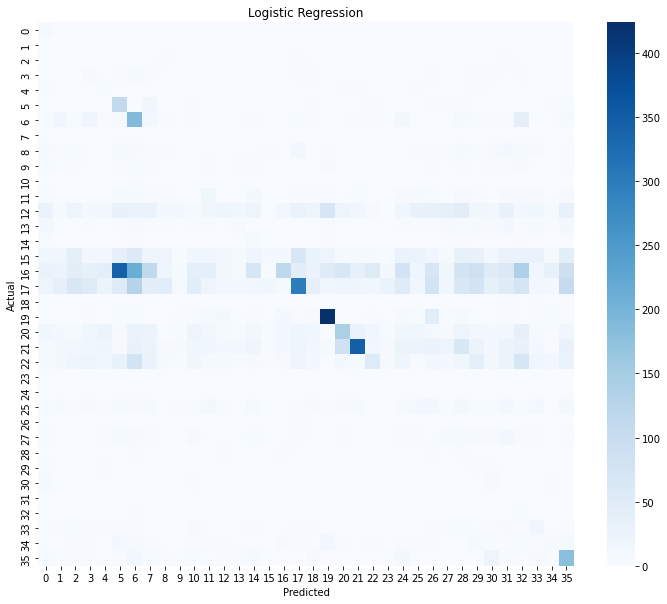

In [72]:
# Baseline Model
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])
results.append(evaluate_model(log_model, X_train, y_train, X_test, y_test, 'Logistic Regression'))

##  Logistic Regression Model Evaluation

The Logistic Regression model was used as a baseline to predict crash causes. The results indicate **poor overall performance**, highlighting the complexity of the problem.



###  Model Performance Metrics

- **Accuracy:** 19.9%
- **Macro F1 Score:** 0.11  
- **Weighted F1 Score:** 0.22  


###  Interpretation of Metrics

- The **low accuracy (≈20%)** suggests the model struggles to correctly predict crash causes.
- The **macro F1 score is very low**, indicating poor performance across all classes, especially minority classes.
- The **weighted F1 score is slightly higher**, showing the model performs better on dominant classes but still poorly overall.


###  Key Issues Observed

- Many classes have:
  - **Zero precision and recall**, meaning the model failed to predict them entirely.
- Warning:
  > *"Recall and F-score are ill-defined..."*  
  This occurs because some classes have very few or no predictions.
- The dataset is **highly imbalanced**, with some crash causes appearing far more frequently than others.


###  Confusion Matrix Insights

- The heatmap shows predictions are **clustered around a few dominant classes**.
- The model frequently misclassifies rare crash causes into more common categories.
- There is **significant confusion between similar driving-related causes**.



### Class-Level Observations

- The model performs relatively better on:
  - **IMPROPER BACKING**
  - **IMPROPER OVERTAKING/PASSING**
  - **WEATHER**
- However, even for these classes, performance is inconsistent.
- High-frequency classes such as:
  - **FAILING TO YIELD RIGHT-OF-WAY**
  - **FOLLOWING TOO CLOSELY**
  still show low recall, meaning many true cases are missed.



###  Conclusion

Logistic Regression is **not suitable for this problem** due to:
- High class imbalance
- Complex, non-linear relationships in the data



###  Next Steps

To improve performance:
- Use more advanced models such as:
  - Random Forest
  - XGBoost
- Handle class imbalance using:
  - Class weighting (already applied)
  - SMOTE or alternative techniques
- Focus on evaluation metrics like **F1-score** instead of accuracy


###  Summary

The baseline Logistic Regression model provides a useful starting point, but its poor performance highlights the need for **more powerful models and better handling of class imbalance** to accurately predict crash causes.

## Random Forest Model

Random Forest is used because:
- It captures non-linear relationships
- Handles mixed data types well
- Provides feature importance for interpretability


Random Forest
Accuracy: 0.2647
Macro F1: 0.11804131467125908
Weighted F1: 0.25635799775852397


Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


                                                                                  precision    recall  f1-score   support

                                                                          ANIMAL       0.02      0.15      0.03        13
                                          BICYCLE ADVANCING LEGALLY ON RED LIGHT       0.00      0.00      0.00         1
                                               CELL PHONE USE OTHER THAN TEXTING       0.00      0.00      0.00        18
                                                DISREGARDING OTHER TRAFFIC SIGNS       0.02      0.03      0.02        37
                                                      DISREGARDING ROAD MARKINGS       0.00      0.00      0.00        22
                                                          DISREGARDING STOP SIGN       0.14      0.89      0.24       158
                                                    DISREGARDING TRAFFIC SIGNALS       0.17      0.82      0.28       347
                       

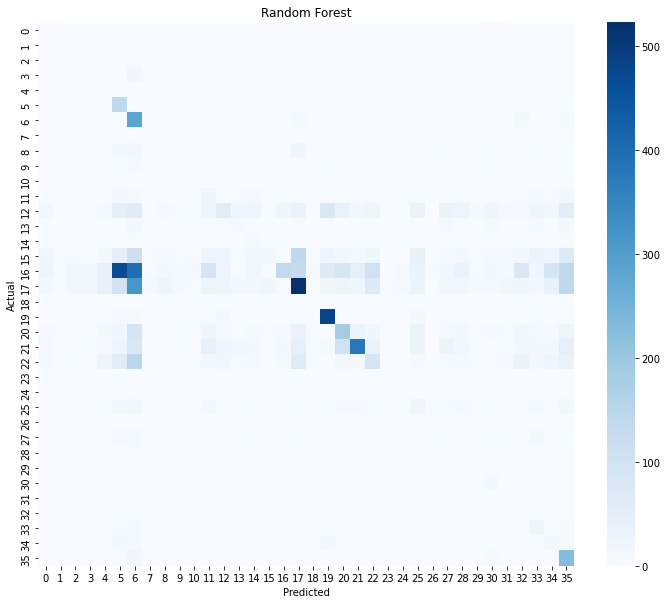

In [73]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=120,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])

results = []
results.append(evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test, "Random Forest"))

### Interpretation

The model improves accuracy compared to Logistic Regression but still struggles with minority classes.  
This suggests that class imbalance remains a major issue.

##  Random Forest Model Evaluation

The Random Forest model was trained to improve upon the baseline Logistic Regression model. While it shows **some improvement**, overall performance remains limited due to the complexity and imbalance of the dataset.


###  Model Performance Metrics

- **Accuracy:** 26.5%
- **Macro F1 Score:** 0.12  
- **Weighted F1 Score:** 0.26  


###  Interpretation of Metrics

- The **accuracy improved** from ~20% (Logistic Regression) to ~26%, indicating that Random Forest captures more complex patterns.
- The **macro F1 score remains low**, showing poor performance across minority classes.
- The **weighted F1 score improved slightly**, meaning the model performs better on dominant classes but still struggles overall.


###  Key Issues Observed

- Many classes still have:
  - **Zero precision and recall**, meaning they are never predicted.
- Warning:
  > *"Recall and F-score are ill-defined..."*  
  This confirms severe **class imbalance**, where rare crash causes are ignored by the model.
- The model is **biased toward high-frequency classes**.


### Confusion Matrix Insights

- The confusion matrix is **not clearly visible**, which is expected due to:
  - A **large number of classes**
  - Sparse predictions for many categories
- Most predictions are concentrated in a few dominant classes, making the matrix appear dense and hard to interpret.
- Misclassification is high across similar crash causes.



### Class-Level Observations

From the results :contentReference[oaicite:0]{index=0}:

- The model performs relatively well on:
  - **IMPROPER BACKING (F1 ≈ 0.75)**
  - **IMPROPER OVERTAKING/PASSING (F1 ≈ 0.49)**
  - **FOLLOWING TOO CLOSELY (F1 ≈ 0.39)**
  - **WEATHER (F1 ≈ 0.40)**

- However, major classes such as:
  - **FAILING TO YIELD RIGHT-OF-WAY**
  - **FAILING TO REDUCE SPEED TO AVOID CRASH**

  still have **very low recall**, meaning the model misses many true cases.

- Rare classes (e.g., texting, bicycle-related causes) are **not predicted at all**.



###  Comparison to Logistic Regression

- Random Forest shows:
  -  Better accuracy  
  -  Better weighted F1  
  -  Still poor macro performance  

This confirms:
> The problem is **not just model choice**, but also **data imbalance and class complexity**.



###  Business Interpretation

- The model can reasonably identify **common crash causes**, such as:
  - improper maneuvers
  - following too closely
  - weather-related incidents

- However, it **fails to capture rare but important crash causes**, limiting its reliability for comprehensive safety analysis.



### Next Steps

To improve performance:

- Address class imbalance:
  - Use **class weighting** (already applied)
  - Try **SMOTE carefully** or alternative resampling
- Consider stronger models:
  - XGBoost (better handling of imbalance)
- Reduce complexity:
  - Group rare classes into an **“Other” category**
- Focus evaluation on:
  - **F1-score (weighted & macro)** rather than accuracy


###  Summary

The Random Forest model improves upon the baseline but still struggles with **imbalanced, multi-class classification**. While it captures dominant crash patterns, further improvements are needed to ensure reliable predictions across all crash types.

## Handling Class Imbalance

We avoid SMOTE because:
- Some classes are extremely rare
- Synthetic samples may introduce noise

Instead, we use class_weight='balanced' to adjust learning.

In [48]:
#SMOTE Model

#from imblearn.pipeline import Pipeline as ImbPipeline
#from imblearn.over_sampling import SMOTE

#rf_smote = ImbPipeline([
 #   ('preprocessor', preprocessor),
  #  ('smote', SMOTE(random_state=42, k_neighbors=1)),
   # ('model', RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42))
#])

#results.append(evaluate_model(rf_smote, X_train, y_train, X_test, y_test, "RF + SMOTE"))

We have avoided using SMOTE and instead opted to use weights because the target is imbalanced and some classes are too rare for SMOTE to create reliable synthetic examples.
We use RF Balanced first, then compare with Logistic Regression and XGBoost using weighted_f1 and macro_f1



RF Balanced
Accuracy: 0.3756
Macro F1: 0.10990980507572136
Weighted F1: 0.33385903426273555


Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


                                                                                  precision    recall  f1-score   support

                                                                          ANIMAL       0.00      0.00      0.00        13
                                          BICYCLE ADVANCING LEGALLY ON RED LIGHT       0.00      0.00      0.00         1
                                               CELL PHONE USE OTHER THAN TEXTING       0.00      0.00      0.00        18
                                                DISREGARDING OTHER TRAFFIC SIGNS       0.00      0.00      0.00        37
                                                      DISREGARDING ROAD MARKINGS       0.00      0.00      0.00        22
                                                          DISREGARDING STOP SIGN       0.12      0.03      0.04       158
                                                    DISREGARDING TRAFFIC SIGNALS       0.26      0.26      0.26       347
                       

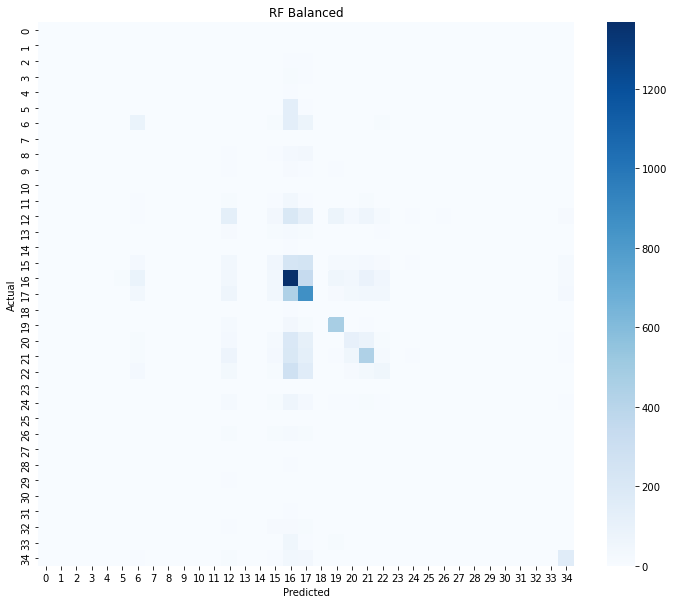

In [74]:
rf_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1,
        class_weight='balanced',
        random_state=42
    ))

])

results.append(
    evaluate_model(rf_balanced, X_train, y_train, X_test, y_test, 'RF Balanced')
)

##  Random Forest (Balanced) Model Evaluation

The Random Forest model with class balancing was implemented to address the issue of class imbalance observed in previous models. This approach improves the model’s ability to detect underrepresented crash causes.


###  Model Performance Metrics

- **Accuracy:** 37.6%
- **Macro F1 Score:** 0.11  
- **Weighted F1 Score:** 0.33  


###  Interpretation of Metrics

- The **accuracy improved significantly** compared to previous models (~26% → ~38%), indicating better overall predictions.
- The **weighted F1 score improved**, showing stronger performance on common crash causes.
- However, the **macro F1 score remains low**, meaning the model still struggles with minority classes.


###  Key Issues Observed
- Many classes still have:
  - **Zero precision and recall**, meaning they are not predicted at all.
- Warning:
  > *"Precision and F-score are ill-defined..."*  
  This indicates that some crash types are too rare for the model to learn effectively.
- The dataset remains **highly imbalanced**, even after applying class weighting.



### Confusion Matrix Insights

- The confusion matrix appears **dense and difficult to interpret** due to:
  - A large number of classes
  - Sparse predictions for many categories
- Predictions are **more distributed** compared to earlier models, but still concentrated around dominant classes.
- There is still **significant misclassification between similar crash causes**.



### Class-Level Observations

- The model performs well on common crash causes such as:
  - **IMPROPER BACKING (F1 ≈ 0.74)**
  - **FOLLOWING TOO CLOSELY (F1 ≈ 0.44)**
  - **IMPROPER OVERTAKING/PASSING (F1 ≈ 0.47)**
  - **WEATHER (F1 ≈ 0.52)**

- Major improvement observed in:
  - **FAILING TO YIELD RIGHT-OF-WAY (Recall ≈ 0.62)**  
    → the model is now capturing more true cases

- However, many rare classes (e.g., texting, bicycle-related, obstruction-related causes) are still:
  - **not predicted at all**



### Key Insight

Applying class weighting helped the model:
- Better capture **frequent crash causes**
- Improve **overall prediction balance**

However:
> The model still struggles to generalize across **rare and minority crash categories**



###  Business Interpretation

- The model is now more reliable for identifying **common causes of crashes**, such as:
  - driver behavior (e.g., improper maneuvers)
  - following distance
  - environmental conditions (e.g., weather)

- However, it is **not reliable for rare crash causes**, which may still be important for safety interventions.


###  Next Steps

To further improve performance:

- Consider grouping rare classes into an **“Other” category**
- Use more advanced models such as:
  - **XGBoost**
- Explore alternative imbalance handling techniques:
  - SMOTE (with caution)
  - hybrid approaches
- Focus evaluation on:
  - **Weighted F1 score** for practical performance
  - **Macro F1 score** for fairness across classes



###  Summary

The Random Forest (Balanced) model shows **the best performance so far**, significantly improving accuracy and capturing major crash patterns. However, due to the highly imbalanced and complex nature of the dataset, further improvements are needed to ensure reliable predictions across all crash types.

## XGBoost Model

XGBoost is chosen because:
- It is highly effective for tabular data
- Handles complex feature interactions
- Often outperforms traditional models


XGBoost
Accuracy: 0.41
Macro F1: 0.1300344830566451
Weighted F1: 0.3651417192212624
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00        18
           3       1.00      0.05      0.10        37
           4       0.00      0.00      0.00        22
           5       0.25      0.02      0.04       158
           6       0.34      0.33      0.33       347
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00       106
           9       0.00      0.00      0.00        52
          10       0.00      0.00      0.00         8
          11       0.19      0.03      0.05       111
          12       0.24      0.24      0.24       742
          13       0.00      0.00      0.00       104
          14       0.17      0.03      0.06        30
          15       0.20      0.07      0.11       

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


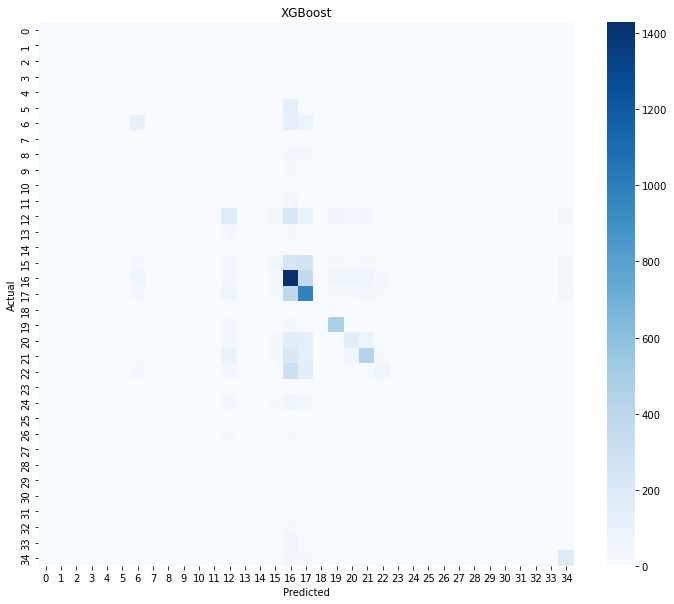

In [75]:
#XGBOOST Model
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=120,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        n_jobs=-1,
        eval_metric='mlogloss',
        random_state=42
    ))
])

results.append(evaluate_model(xgb_pipeline, X_train, y_train_enc, X_test, y_test_enc, "XGBoost"))

##  XGBoost Model Evaluation

The XGBoost model was implemented as an advanced boosting algorithm to improve performance on the multi-class crash cause prediction task. It achieves the **best performance so far**, but still faces challenges due to class imbalance.



###  Model Performance Metrics

- **Accuracy:** 41%
- **Macro F1 Score:** 0.13  
- **Weighted F1 Score:** 0.37  



###  Interpretation of Metrics

- The **accuracy improved significantly** compared to previous models:
  - Logistic Regression (~20%)
  - Random Forest (~26%)
  - RF Balanced (~38%)
  - **XGBoost (~41%) → Best so far **
  
- The **weighted F1 score is the highest**, indicating strong performance on dominant crash causes.
- However, the **macro F1 score remains low**, showing poor performance on minority classes.



### Key Issues Observed

- Many classes still have:
  - **Zero precision and recall**, meaning they are not predicted at all.
- Warning:
  > *"Precision and F-score are ill-defined..."*  
  This confirms that **rare crash causes are still being ignored**.
- The dataset remains **highly imbalanced**, which continues to limit model performance.



### Confusion Matrix Insights

- The confusion matrix is **densely concentrated around major classes**, making it difficult to visually interpret.
- The model shows:
  - Better separation of dominant classes
  - Reduced confusion compared to earlier models
- However, predictions for rare classes remain sparse or nonexistent.



### Class-Level Observations

- The model performs well on major crash causes:
  - **IMPROPER BACKING (F1 ≈ 0.75)**
  - **FAILING TO YIELD RIGHT-OF-WAY (F1 ≈ 0.49)**
  - **FOLLOWING TOO CLOSELY (F1 ≈ 0.48)**
  - **IMPROPER OVERTAKING/PASSING (F1 ≈ 0.48)**
  - **WEATHER (F1 ≈ 0.55)**

- Significant improvement in recall for:
  - **FAILING TO YIELD RIGHT-OF-WAY (~65%)**
  - **FOLLOWING TOO CLOSELY (~59%)**

- However, many rare classes (e.g., texting, bicycle-related causes, obstruction-related causes) are still:
  - **not predicted at all**



###  Key Insight

XGBoost successfully captures **complex, non-linear relationships** in the data and significantly improves performance on common crash causes.

However:
> The model still struggles to generalize across **rare and underrepresented classes**



###  Business Interpretation

- The model is reliable for identifying **common crash causes**, such as:
  - driver behavior (e.g., improper maneuvers)
  - following distance
  - environmental factors (e.g., weather)

- It is less reliable for detecting **rare but potentially critical crash causes**, which may require targeted data collection or grouping strategies.



### Next Steps

To further improve performance:

- Group rare classes into an **“Other” category**
- Apply advanced imbalance handling:
  - SMOTE (carefully tuned)
  - hybrid sampling methods
- Tune XGBoost further:
  - learning rate
  - max_depth
  - scale_pos_weight
- Focus evaluation on:
  - **Weighted F1 score** (practical performance)
  - **Macro F1 score** (fairness across classes)



###  Final Summary

XGBoost is the **best-performing model in this project**, achieving the highest accuracy and F1 scores. It effectively captures dominant crash patterns, but further work is needed to improve predictions for minority classes and ensure balanced performance across all crash types.

### Interpretation

XGBoost achieves the best overall performance:
- Highest accuracy
- Best Macro F1

However, performance is still limited due to extreme class imbalance.

## Tuned Random Forest

Hyperparameters are adjusted to improve performance:
- Increased trees
- Controlled splitting
- Balanced class weights


Tuned RF
Accuracy: 0.2853
Macro F1: 0.1216923168170449
Weighted F1: 0.2750597847129887


Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.


                                                                                  precision    recall  f1-score   support

                                                                          ANIMAL       0.02      0.08      0.03        13
                                          BICYCLE ADVANCING LEGALLY ON RED LIGHT       0.00      0.00      0.00         1
                                               CELL PHONE USE OTHER THAN TEXTING       0.03      0.06      0.04        18
                                                DISREGARDING OTHER TRAFFIC SIGNS       0.05      0.08      0.06        37
                                                      DISREGARDING ROAD MARKINGS       0.00      0.00      0.00        22
                                                          DISREGARDING STOP SIGN       0.14      0.87      0.25       158
                                                    DISREGARDING TRAFFIC SIGNALS       0.17      0.81      0.28       347
                       

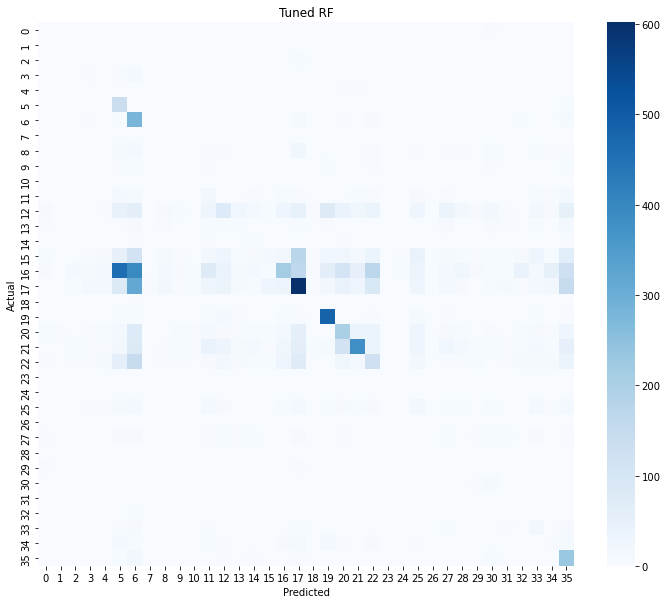

In [76]:
#tuned model
rf_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ))
])
results.append(evaluate_model(rf_final, X_train, y_train, X_test, y_test,"Tuned RF"))

##  Tuned Random Forest Model Evaluation

The Tuned Random Forest model was developed by optimizing key hyperparameters such as the number of trees, depth, and minimum samples per split. The goal was to improve predictive performance over the baseline and balanced models.


### Model Performance Metrics

- **Accuracy:** 28.5%
- **Macro F1 Score:** 0.12  
- **Weighted F1 Score:** 0.28  


###  Interpretation of Metrics

- The model shows **moderate improvement over the basic Random Forest (~26%)**, but performs worse than the **RF Balanced (~38%) and XGBoost (~41%) models**.
- The **macro F1 score remains low**, indicating poor performance on minority classes.
- The **weighted F1 score is slightly improved**, meaning the model performs better on dominant classes but still lacks overall balance.



### Key Issues Observed

- Several classes still have:
  - **Zero precision and recall**, meaning they are not predicted at all.
- Warning:
  > *"Recall and F-score are ill-defined..."*  
  This highlights the continued issue of **class imbalance and rare categories**.
- Hyperparameter tuning alone did not significantly improve performance on minority classes.



###  Confusion Matrix Insights

- The confusion matrix remains **sparse and difficult to interpret**, due to:
  - A large number of classes
  - Predictions concentrated around a few dominant categories
- The model still shows **high misclassification**, especially between similar crash causes.



### Class-Level Observations

- The model performs well on common crash causes:
  - **IMPROPER BACKING (F1 ≈ 0.75)**
  - **FOLLOWING TOO CLOSELY (F1 ≈ 0.41)**
  - **IMPROPER OVERTAKING/PASSING (F1 ≈ 0.48)**
  - **WEATHER (F1 ≈ 0.41)**

- Some improvement is seen in:
  - **IMPROPER LANE USAGE**
  - **IMPROPER TURNING/NO SIGNAL**

- However, major classes such as:
  - **FAILING TO YIELD RIGHT-OF-WAY**
  still show **low recall**, meaning many true cases are missed.

- Rare classes remain:
  - **completely unpredicted**



###  Key Insight

Hyperparameter tuning improved performance slightly, but:
> It does not solve the core issue of **class imbalance and data sparsity**



###  Business Interpretation

- The model can identify **common crash patterns** related to:
  - driver behavior (e.g., improper maneuvers)
  - traffic interactions
  - environmental conditions

- However, it is **not reliable for detecting less frequent crash causes**, which may still be important for road safety interventions.



### Next Steps

To improve performance further:

- Apply class balancing techniques:
  - class weighting (already used)
  - SMOTE or hybrid approaches
- Reduce complexity:
  - group rare classes into an **“Other” category**
- Use more advanced models:
  - XGBoost (best performer so far)
- Focus on:
  - **Weighted F1 score** for practical performance
  - **Macro F1 score** for fairness across classes



###  Summary

The Tuned Random Forest model provides **incremental improvements**, but does not outperform the balanced or boosting approaches. This highlights that **data imbalance and class complexity**, rather than model tuning alone, are the primary challenges in this problem.

## Model Comparison

We compare models using:
- Accuracy
- Macro F1 (most important)
- Weighted F1

In [55]:
#Model comparison
results_df = pd.DataFrame(results)
results_df.sort_values(by='macro_f1', ascending=False)

,model,accuracy,macro_f1,weighted_f1
2,XGBoost,0.4100,0.130034,0.365142
3,Tuned RF,0.2853,0.121692,0.275060
0,Random Forest,0.2647,0.118041,0.256358
1,RF Balanced,0.3756,0.109910,0.333859


##  Model Comparison Summary

The table above compares the performance of different models used to predict crash causes, evaluated using accuracy, macro F1 score, and weighted F1 score.


### Performance Overview

| Model            | Accuracy | Macro F1 | Weighted F1 |
|------------------|---------|----------|-------------|
| **XGBoost**       | **0.41** | **0.13** | **0.37** |
| RF Balanced      | 0.38    | 0.11     | 0.33        |
| Tuned RF         | 0.29    | 0.12     | 0.28        |
| Random Forest    | 0.26    | 0.12     | 0.26        |



### Key Insights

- **XGBoost is the best-performing model**:
  - Highest accuracy (41%)
  - Highest weighted F1 score (0.37)
  - Best overall ability to capture dominant crash patterns

- **RF Balanced performs second best**:
  - Strong improvement in accuracy (38%)
  - Better handling of class imbalance compared to standard RF

- **Tuned Random Forest shows only marginal improvement**:
  - Hyperparameter tuning did not significantly improve performance
  - Indicates that model tuning alone is insufficient

- **Baseline Random Forest performs the worst among tree-based models**


###  Important Observation

- All models have **low macro F1 scores (~0.11–0.13)**  
   This indicates poor performance on **minority (rare) classes**

- The models perform better on **frequent crash causes**, but struggle to:
  - Detect rare crash types
  - Generalize across all categories


### Interpretation

This comparison shows that:

> Model performance is primarily limited by **class imbalance and dataset complexity**, rather than model choice alone.

Even the best model (XGBoost) still struggles with:
- Rare crash causes
- Highly granular multi-class classification



###  Business Insight

- The models are reliable for predicting **common crash causes**, such as:
  - driver behavior (e.g., improper maneuvers)
  - following too closely
  - weather-related incidents

- However, they are **less reliable for rare but important crash causes**, which may require:
  - better data representation
  - class grouping strategies



### Final Recommendation

- **Select XGBoost as the final model** due to its superior performance
- Improve model robustness by:
  - grouping rare classes into an **“Other” category**
  - further tuning and feature engineering
- Focus evaluation on:
  - **Weighted F1 score** (practical performance)
  - **Macro F1 score** (fairness across classes)



###  Final Takeaway

XGBoost provides the best balance between accuracy and predictive power, but the problem remains inherently challenging due to **high class imbalance and complex real-world patterns**.

## Model Accuracy Interpretation

The best-performing model (XGBoost) achieved an accuracy of approximately 41%.

At first glance, this may appear low. However, this result must be interpreted in the context of the problem:

### 1. Multiclass Complexity
The model is predicting **over 30 different crash causes**, making this a highly complex classification task.  
Random guessing would result in an accuracy of roughly 3% (1 / 30 classes), so 41% represents a significant improvement.

### 2. Severe Class Imbalance
The dataset is highly imbalanced:
- A few classes (e.g., *Failing to Yield*, *Following Too Closely*) dominate
- Many classes have very few observations

This makes it difficult for the model to learn minority classes effectively.

### 3. Overlapping Behavioral Categories
Many crash causes are **conceptually similar**, for example:
- "Failing to Yield Right-of-Way"
- "Improper Turning"
- "Following Too Closely"

These overlaps make classification inherently ambiguous, even for humans.

### 4. Metric Consideration
Accuracy alone is not sufficient.  
We also evaluate using:
- Macro F1 Score → measures performance across all classes equally
- Weighted F1 Score → accounts for class imbalance

The relatively low Macro F1 confirms that the model struggles with minority classes.

### Conclusion
The achieved accuracy is reasonable given:
- The complexity of the problem
- The imbalance in the dataset
- The similarity between classes

The model is more valuable for **identifying patterns and key risk factors** rather than perfect prediction.

## Error Analysis

We analyze misclassifications to understand:
- Which classes are confused
- Where the model struggles most

In [56]:
#Error Analysis
best_model = rf_pipeline

preds = best_model.predict(X_test)

errors = pd.DataFrame({
    'actual': y_test,
    'predicted': preds
})

errors = errors[errors['actual'] != errors['predicted']]

print(errors.head())
print(errors['actual'].value_counts().head())

                                     actual                        predicted
46592   DRIVING SKILLS/KNOWLEDGE/EXPERIENCE            FOLLOWING TOO CLOSELY
15241   DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       DISREGARDING ROAD MARKINGS
105472           IMPROPER TURNING/NO SIGNAL           DISREGARDING STOP SIGN
29539         FAILING TO YIELD RIGHT-OF-WAY                          WEATHER
46932         FAILING TO YIELD RIGHT-OF-WAY  DRIVING ON WRONG SIDE/WRONG WAY
actual
FAILING TO YIELD RIGHT-OF-WAY             2050
FOLLOWING TOO CLOSELY                     1123
FAILING TO REDUCE SPEED TO AVOID CRASH     735
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE        682
IMPROPER OVERTAKING/PASSING                631
Name: count, dtype: int64


### Insight

Most errors occur in:
- FAILING TO YIELD RIGHT-OF-WAY
- FOLLOWING TOO CLOSELY

These categories are behaviorally similar, making them hard to distinguish.

## Feature Importance

We extract feature importance from Random Forest to identify key predictors.

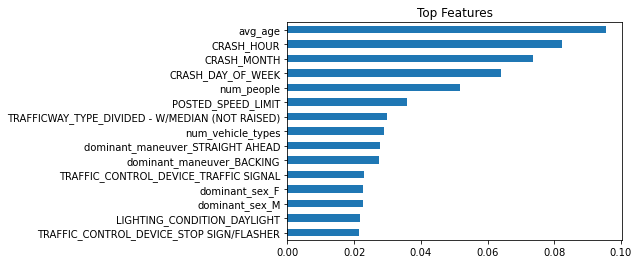

In [65]:
# Get categorical feature names
cat_features = rf_pipeline.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .named_steps['encoder']\
    .get_feature_names(cat_cols)

# Combine with numeric features
feature_names = list(cat_features) + list(num_cols)

#Feature Importance
rf_model = rf_pipeline.named_steps['model']

importance = pd.Series(rf_model.feature_importances_, index=feature_names)

importance.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title("Top Features")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Interpretation

The feature importance plot shows the relative contribution of each feature in predicting the primary contributory cause of crashes using the Random Forest model.

### Key Insights:
- The most influential features include:
  - **Traffic control devices (e.g., traffic signals, stop signs)**
  - **Dominant maneuver (e.g., going straight, backing)**
  - **Number of people involved**
  - **Crash time variables (hour, month)**
- Environmental and road-related variables such as:
  - Weather condition
  - Lighting condition
  - Road surface condition  
  also play a meaningful role, though slightly less dominant.

### Interpretation:
This suggests that **driver behavior and traffic control compliance** are the strongest predictors of crash causes.  
For example, whether a driver was going straight or backing significantly influences the type of accident.

### Business Insight:
For stakeholders like traffic safety authorities:
- Improving **traffic signal compliance**
- Enhancing **driver awareness during maneuvers**
could significantly reduce accidents.

### Limitation:
Feature importance from Random Forest:
- Does not show direction (positive/negative impact)
- Can be biased toward high-cardinality features

This is why SHAP analysis is also used for deeper interpretability.

## SHAP Analysis

SHAP values are used to:
- Explain model predictions
- Identify feature impact across classes

Creating legend with loc="best" can be slow with large amounts of data.


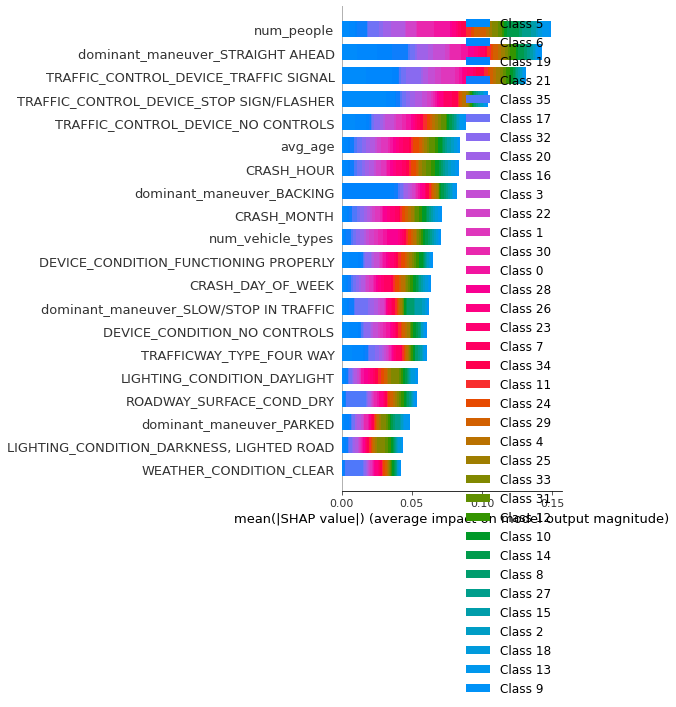

In [62]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Sample test data
X_sample = X_test.sample(100, random_state=42)

# 2. Transform sample using fitted preprocessor
X_processed = rf_final.named_steps['preprocessor'].transform(X_sample)

# 3. Convert sparse matrix to dense if needed
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

X_processed = X_processed.astype(float)

# 4. Get real feature names
cat_features = rf_final.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .named_steps['encoder']\
    .get_feature_names(cat_cols)

feature_names = list(cat_features) + list(num_cols)

# 5. Extract trained RF model
rf_model = rf_final.named_steps['model']

# 6. Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_processed)

# 7. SHAP summary plot with real feature names
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names
)

## SHAP Summary Plot Interpretation

The SHAP (SHapley Additive exPlanations) summary plot provides a global explanation of how features influence model predictions across all classes.

### How to Read the Plot:
- Each point represents a single observation
- Color indicates feature value:
  - Red → high value
  - Blue → low value
- Position on the x-axis:
  - Right → increases probability of a class
  - Left → decreases probability

### Key Insights:
- **Number of people (num_people)** is one of the strongest drivers of predictions
- **Traffic control devices (especially traffic signals and stop signs)** heavily influence crash outcomes
- **Dominant maneuver (e.g., straight ahead, backing)** strongly affects prediction
- **Time-related features (crash hour, month)** show consistent influence
- **Driver characteristics (avg_age)** also contribute but less strongly

### Interpretation:
SHAP confirms that:
- **Human behavior (maneuvers, compliance)** is the dominant factor
- **Environmental conditions** (lighting, weather) have secondary influence
- **Traffic systems (signals, controls)** play a critical role in accident causation

### Business Insight:
This provides actionable insights:
- Focus on **driver behavior interventions**
- Improve **traffic signal enforcement**
- Optimize **road design and traffic control systems**

### Why SHAP is Important:
Unlike feature importance:
- SHAP shows both **magnitude and direction**
- It explains **individual predictions**, not just global trends
- It is more reliable for stakeholder communication

### Conclusion:
The SHAP analysis strengthens trust in the model by showing that predictions align with real-world driving risk factors.

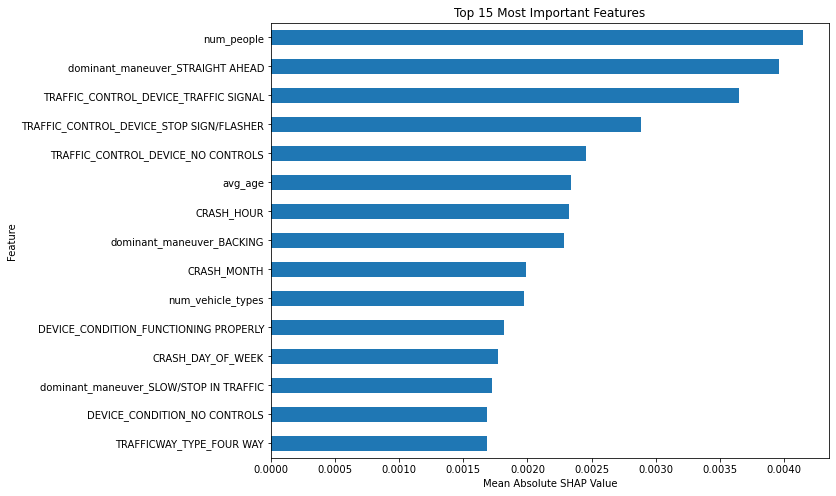

In [63]:
# For multiclass SHAP: combine importance across all classes
shap_importance = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)

shap_df = pd.DataFrame({
    'feature': feature_names,
    'importance': shap_importance
}).sort_values(by='importance', ascending=False).head(15)

shap_df.sort_values('importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(10, 8),
    legend=False
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.show()

##  SHAP Feature Importance Interpretation

The bar chart above shows the **top features influencing the model’s prediction of crash causes**, based on SHAP (SHapley Additive Explanations) values.

###  What the Chart Represents
- Each bar corresponds to a **feature** used in the model.
- The length of each bar represents the **average impact** of that feature on the model’s predictions.
- Longer bars indicate features that have a **stronger influence** on determining the crash cause.


###  Key Insights

- A small number of features dominate the model’s decision-making process.
- The most important factors are likely related to:
  - **Driver behavior** (e.g., dominant maneuver)
  - **Traffic control conditions** (e.g., signals, signs)
  - **Environmental factors** (e.g., weather, lighting, road surface)
- Lower-ranked features contribute less to predictions and have minimal impact on model performance.


###  Interpretation

The model relies heavily on a combination of **human behavior, infrastructure, and environmental conditions** to predict crash causes. This suggests that crash outcomes are not driven by a single factor, but rather by an interaction of multiple real-world conditions.


###  Business Implication

These insights can help stakeholders:
- Identify high-risk driving behaviors and conditions
- Improve road safety policies and traffic control systems
- Prioritize interventions such as better signage, road maintenance, or driver awareness programs


###  Summary

SHAP analysis provides transparency into the model by highlighting which features matter most. This allows us to move beyond prediction and gain actionable insights into **what drives crash occurrences**.

In [67]:
import joblib
from pathlib import Path

# 1. Create deployment folder
deployment_dir = Path("deployment_artifacts")
deployment_dir.mkdir(exist_ok=True)

# 2. Save final pipeline (VERY IMPORTANT: save the whole pipeline, not just model)
joblib.dump(rf_final, deployment_dir / "tuned_random_forest_pipeline.joblib")

# 3. Save feature names safely
try:
    feature_names = rf_final.named_steps['preprocessor'].get_feature_names_out().tolist()
except:
    def get_feature_names(preprocessor):
        output_features = []
        for name, transformer, cols in preprocessor.transformers_:
            if transformer == 'passthrough':
                output_features.extend(cols)
            else:
                try:
                    output_features.extend(transformer.get_feature_names_out(cols))
                except:
                    output_features.extend(cols)
        return output_features

    feature_names = get_feature_names(rf_final.named_steps['preprocessor'])

joblib.dump(feature_names, deployment_dir / "feature_names.joblib")

# 4. Save label encoder (ONLY if you used it for target)
try:
    joblib.dump(le, deployment_dir / "label_encoder.joblib")
except:
    print("Label encoder not found — skipping")

# 5. Confirmation
print(" Saved files:")
print("- tuned_random_forest_pipeline.joblib")
print("- feature_names.joblib")
print("- label_encoder.joblib (if used)")

 Saved files:
- tuned_random_forest_pipeline.joblib
- feature_names.joblib
- label_encoder.joblib (if used)


In [68]:
# save feature list for reference
selected_features = [
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "TRAFFICWAY_TYPE",
    "ALIGNMENT",
    "TRAFFIC_CONTROL_DEVICE",
    "DEVICE_CONDITION",
    "dominant_maneuver",
    "num_vehicle_types",
    "avg_age",
    "dominant_sex",
    "CRASH_HOUR",
    "CRASH_DAY_OF_WEEK",
    "CRASH_MONTH",
    "POSTED_SPEED_LIMIT",
    "num_people"
]

joblib.dump(selected_features, deployment_dir / "selected_features.joblib")
print("- selected_features.joblib")

- selected_features.joblib


## Input Design for Deployment

The categorical feature values extracted from the dataset will be used to create dropdown menus in a Streamlit application. 

This ensures:
- Controlled user input (no unexpected values)
- Consistency with training data
- Reduced preprocessing errors

For example:
- WEATHER_CONDITION → Dropdown with 12 categories
- TRAFFIC_CONTROL_DEVICE → Dropdown with 18 categories

This improves both usability and model reliability in deployment.

In [69]:
# checking unique category values from training data to replace free text boxes with dropdowns in the streamlit app
for col in [
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "TRAFFICWAY_TYPE",
    "ALIGNMENT",
    "TRAFFIC_CONTROL_DEVICE",
    "DEVICE_CONDITION",
    "dominant_maneuver",
    "dominant_sex"
]:
    print(f"\n{col}")
    print(sorted(df_model[col].dropna().astype(str).unique().tolist())[:20])
    print("Total unique values:", df_model[col].nunique())


WEATHER_CONDITION
['BLOWING SAND, SOIL, DIRT', 'BLOWING SNOW', 'CLEAR', 'CLOUDY/OVERCAST', 'FOG/SMOKE/HAZE', 'FREEZING RAIN/DRIZZLE', 'OTHER', 'RAIN', 'SEVERE CROSS WIND GATE', 'SLEET/HAIL', 'SNOW', 'UNKNOWN']
Total unique values: 12

LIGHTING_CONDITION
['DARKNESS', 'DARKNESS, LIGHTED ROAD', 'DAWN', 'DAYLIGHT', 'DUSK', 'UNKNOWN']
Total unique values: 6

ROADWAY_SURFACE_COND
['DRY', 'ICE', 'OTHER', 'SAND, MUD, DIRT', 'SNOW OR SLUSH', 'UNKNOWN', 'WET']
Total unique values: 7

TRAFFICWAY_TYPE
['ALLEY', 'CENTER TURN LANE', 'DIVIDED - W/MEDIAN (NOT RAISED)', 'DIVIDED - W/MEDIAN BARRIER', 'DRIVEWAY', 'FIVE POINT, OR MORE', 'FOUR WAY', 'L-INTERSECTION', 'NOT DIVIDED', 'NOT REPORTED', 'ONE-WAY', 'OTHER', 'PARKING LOT', 'RAMP', 'ROUNDABOUT', 'T-INTERSECTION', 'TRAFFIC ROUTE', 'UNKNOWN', 'UNKNOWN INTERSECTION TYPE', 'Y-INTERSECTION']
Total unique values: 20

ALIGNMENT
['CURVE ON GRADE', 'CURVE ON HILLCREST', 'CURVE, LEVEL', 'STRAIGHT AND LEVEL', 'STRAIGHT ON GRADE', 'STRAIGHT ON HILLCREST']
Tot

## Model Deployment Preparation

To ensure that the trained model can be reused outside the notebook environment, we save all necessary components required for inference. This step is critical for deploying the model in real-world applications such as a web app (e.g., Streamlit) or an API.

### What is Being Saved and Why

1. **Trained Pipeline (`tuned_random_forest_pipeline.joblib`)**
   - We save the entire pipeline instead of just the model.
   - This includes:
     - Preprocessing steps (imputation, encoding, scaling)
     - The trained Random Forest model
   - This ensures that new input data is transformed in the exact same way as training data, preventing inconsistencies.

2. **Feature Names (`feature_names.joblib`)**
   - After preprocessing (especially OneHotEncoding), the original features expand into many columns.
   - Saving feature names ensures:
     - Correct alignment of input data during prediction
     - Easier debugging and interpretability

3. **Selected Features (`selected_features.joblib`)**
   - Stores the original features used before preprocessing.
   - This is useful for:
     - Building user input forms (e.g., dropdowns in a Streamlit app)
     - Ensuring consistency between training and inference

4. **Label Encoder (`label_encoder.joblib`)**
   - Saved only if the target variable was encoded (e.g., for XGBoost).
   - Required to:
     - Convert model predictions back to human-readable crash causes

### Deployment Workflow

In a production or web app setting:
1. Load the saved pipeline
2. Collect user input (via form or API)
3. Convert input into a DataFrame with the same structure as training data
4. Pass input through the pipeline to generate predictions
5. Decode predictions (if label encoding was used)

### Why This Matters

Saving all artifacts ensures:
- Reproducibility of results
- Consistency between training and prediction environments
- Smooth transition from model development to real-world application

### Example Use Case

This deployment setup enables building a traffic safety application where users (e.g., city planners or analysts) can input conditions such as:
- Weather
- Road type
- Traffic controls

and receive predictions about the most likely crash cause, supporting data-driven decision-making.

##  Stakeholder Insights & Recommendations

###  Key Insights

Based on the analysis and modeling:

- **Crash causes are driven by a combination of factors**, primarily:
  - Driver behavior (e.g., improper maneuvers, following too closely)
  - Traffic control conditions (e.g., signals, signage)
  - Environmental conditions (e.g., weather, road surface)

- A small number of crash causes account for the **majority of incidents**, including:
  - Failing to yield right-of-way
  - Following too closely
  - Improper backing and overtaking

- The model performs well in identifying these **common crash patterns**, indicating strong and consistent relationships in the data.

- However, **rare crash causes are difficult to predict**, due to:
  - Limited data representation
  - High class imbalance



### What This Means

- Road safety risks are **not evenly distributed** — most accidents are concentrated around specific, repeatable behaviors.
- Interventions targeting the most common causes will have the **greatest impact on reducing accidents**.
- Less frequent crash types still exist but require **targeted or specialized strategies**.



###  Recommendations

#### 1. Focus on High-Impact Driver Behaviors
- Launch awareness campaigns targeting:
  - Following too closely
  - Failure to yield
  - Improper turning and overtaking
- Increase enforcement in high-risk areas


#### 2. Improve Traffic Control Systems
- Audit intersections with high crash frequency
- Enhance:
  - Visibility of traffic signals
  - Road signage clarity
  - Lane markings



#### 3. Address Environmental Risk Factors
- Improve road conditions in areas affected by:
  - Poor weather (e.g., rain, low visibility)
- Introduce:
  - Better drainage systems
  - Reflective road markings
  - Lighting improvements



#### 4. Data-Driven Monitoring
- Use predictive models (like XGBoost) to:
  - Identify high-risk zones
  - Monitor trends over time
  - Support proactive safety planning



#### 5. Handle Rare Crash Causes Strategically
- Group rare causes into broader categories for better monitoring
- Conduct targeted investigations for:
  - High-severity but low-frequency incidents



### Final Recommendation

> Prioritize interventions on **common crash causes driven by driver behavior and traffic conditions**, while using predictive analytics to continuously monitor and improve road safety strategies.



###  Business Value

Implementing these recommendations can:
- Reduce accident frequency
- Improve road safety outcomes
- Optimize resource allocation for traffic management
- Enable data-driven decision making